# Model V4 — AR(1) with Annual Cycle, Per-Region New Year Effect, Full Reset, and Hierarchical Cost-Per-Person Baseline

**Likelihood:**
$$y_{i,1} \sim \mathcal{N}(\mu_{i,1},\, \tau_i)$$
$$y_{i,t} \sim \mathcal{N}\!\Big(\mu_{i,t} + \phi\,(y_{i,t-1} - \mu_{i,t-1}),\, \tau_i\Big), \quad t = 2,\ldots,T$$

**Mean function (same structure as V3):**
$$\mu_{i,t} = \alpha_i + \beta_i \cos\!\Big(\frac{2\pi t}{52}\Big) + \gamma_i \sin\!\Big(\frac{2\pi t}{52}\Big) + $$
$$\delta_{\text{pre},i}\, \mathbb{1}(t\bmod 52 = 0) + \delta_{\text{mid},i}\, \mathbb{1}(t\bmod 52 = 1) + \delta_{\text{post},i}\, \mathbb{1}(t\bmod 52 = 2) + $$
$$\sigma_{\text{pre}}\, \mathbb{1}(t = 86, i=\text{mid west}) + \sigma_{\text{mid}}\, \mathbb{1}(t = 87, i=\text{mid west}) + \sigma_{\text{post}}\, \mathbb{1}(t = 88, i=\text{mid west})$$

**Hierarchical prior on intercept (V4 key change):**
$$\alpha_i \sim \mathcal{N}(\mu_\lambda \cdot c_i,\; \tau_\alpha)$$

where $c_i$ is the HR cost-per-person for region $i$ (from `hr_cost_per_person.csv`), $\mu_\lambda$ is a global cost coefficient, and $\tau_\alpha$ captures residual region-level variation.

**Other priors:**
$$\beta_i, \gamma_i, \delta_{\text{pre},i}, \delta_{\text{mid},i}, \delta_{\text{post},i} \sim \mathcal{N}(0,\, 10^3) \quad \tau_i \sim \text{Gamma}(0.001,\, 0.001) \quad \phi \sim \text{Uniform}(-1,\, 1)$$
$$\sigma_{\text{pre}},\, \sigma_{\text{mid}},\, \sigma_{\text{post}} \sim \mathcal{N}(0,\, 10^3) \quad \mu_\lambda \sim \mathcal{N}(0,\, 10^3) \quad \tau_\alpha \sim \text{Gamma}(0.001,\, 0.001)$$

**Key difference from V3:** the prior on $\alpha_i$ is centred at $\mu_\lambda \cdot c_i$ — partial pooling toward a cost-scaled expectation rather than a free $\mathcal{N}(0, 10^3)$ prior.

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np
from itertools import combinations

sns.set_theme(style='whitegrid', font_scale=1.2)

# Load raw MCMC samples and observed data
df_og = pd.read_csv('../../data/wide_weekly_scaledPer10k.csv')
raw_df = pd.read_csv('../../data/models/v4/raw_samples.csv')
regions = pd.read_csv('../../data/regions.csv')['region'].tolist()
n_region = len(regions)

# Cost-per-person (the scaler c_i)
cpp_df = pd.read_csv('../../data/hr_cost_per_person.csv')
cost_per_person = cpp_df.set_index('Region').loc[regions, 'CostPerPerson'].values

pd.DataFrame({'Region': regions, 'CostPerPerson': cost_per_person.round(4)})

,Region,CostPerPerson
0,HSE Dublin and Midlands,3.4056
1,HSE Dublin and North East,2.8600
2,HSE Dublin and South East,2.7382
3,HSE Mid West,2.8616
4,HSE South West,2.7032
5,HSE West and North West,3.3068


## HR Cost Per Person by Region

Per-capita HR budget allocation for each HSE region.

**Units:** € thousands per person (k€/person) — total regional HR budget (€) divided by catchment population.

In [60]:
cpp_display = pd.read_csv('../../data/hr_cost_per_person.csv')
cpp_display = cpp_display.set_index('Region').loc[regions].reset_index()
cpp_display.columns = ['Region', 'Cost Per Person (k€/person)']
cpp_display['Cost Per Person (k€/person)'] = cpp_display['Cost Per Person (k€/person)'].round(4)
cpp_display.sort_values('Cost Per Person (k€/person)', ascending=False)

,Region,Cost Per Person (k€/person)
0,HSE Dublin and Midlands,3.4056
5,HSE West and North West,3.3068
3,HSE Mid West,2.8616
1,HSE Dublin and North East,2.8600
2,HSE Dublin and South East,2.7382
4,HSE South West,2.7032


## Load the model parameters

In [61]:
n_weeks = df_og.shape[1] - 1  # exclude Region column

# Time vector (1-based, matching R)
t_vec = np.arange(1, n_weeks + 1)

# Event indicators (matching R model specification)
week_mod = t_vec % 52
ny_pre  = (week_mod == 0).astype(float)
ny_mid  = (week_mod == 1).astype(float)
ny_post = (week_mod == 2).astype(float)
fr_pre  = (t_vec == 86).astype(float)
fr_mid  = (t_vec == 87).astype(float)
fr_post = (t_vec == 88).astype(float)

# Mid West mask
mw = np.array([1.0 if r == 'HSE Mid West' else 0.0 for r in regions])

# Trig components
cos_t = np.cos(2 * np.pi * t_vec / 52)
sin_t = np.sin(2 * np.pi * t_vec / 52)

# Compute mu[i,t]: V4 uses alpha[i] directly (hierarchical prior centred on mu_lambda * c_i)
mu_mean_arr  = np.zeros((n_weeks, n_region))
mu_lower_arr = np.zeros((n_weeks, n_region))
mu_upper_arr = np.zeros((n_weeks, n_region))

for i in range(n_region):
    mu_i = (raw_df[f'alpha[{i+1}]'].values[:, None]
            + raw_df[f'beta[{i+1}]'].values[:, None]      * cos_t[None, :]
            + raw_df[f'gamma[{i+1}]'].values[:, None]     * sin_t[None, :]
            + raw_df[f'delta_pre[{i+1}]'].values[:, None] * ny_pre[None, :]
            + raw_df[f'delta_mid[{i+1}]'].values[:, None] * ny_mid[None, :]
            + raw_df[f'delta_post[{i+1}]'].values[:, None]* ny_post[None, :]
            + raw_df['sigma_pre'].values[:, None]  * (fr_pre  * mw[i])[None, :]
            + raw_df['sigma_mid'].values[:, None]  * (fr_mid  * mw[i])[None, :]
            + raw_df['sigma_post'].values[:, None] * (fr_post * mw[i])[None, :])
    mu_mean_arr[:, i]  = mu_i.mean(axis=0)
    mu_lower_arr[:, i] = np.quantile(mu_i, 0.025, axis=0)
    mu_upper_arr[:, i] = np.quantile(mu_i, 0.975, axis=0)

df_mu       = pd.DataFrame(mu_mean_arr,  columns=regions)
df_mu_lower = pd.DataFrame(mu_lower_arr, columns=regions)
df_mu_upper = pd.DataFrame(mu_upper_arr, columns=regions)

phi_mean = raw_df['phi'].mean()

## Preprocess
Transform the og df into regions (cols) x time (weeks)

In [62]:
df_og = df_og.T
df_og.columns = df_og.iloc[0]
df_og = df_og.drop(df_og.index[0])
df_og = df_og.reset_index(drop=True)

## Make the model estimate df
Formula
y[i,t] ~ dnorm(mu[i,t] + (phi * (y[i,t-1] - mu[i,t-1])), tau[i])

In [63]:
df_mu_t1    = df_mu.iloc[:df_mu.shape[0]-1]
df_og_t1    = df_og.iloc[:df_mu.shape[0]-1]
phi         = phi_mean
df_mu_first = pd.DataFrame([df_mu.iloc[0]])
df_mu_rest  = df_mu.iloc[1:].reset_index(drop=True)
df_ar1 = df_mu_rest + (phi * (df_og_t1 - df_mu_t1))
df_ar1 = pd.concat([df_mu_first, df_ar1], ignore_index=True)
df_ar1

,HSE Dublin and Midlands,HSE Dublin and North East,HSE Dublin and South East,HSE Mid West,HSE South West,HSE West and North West
0,0.86595,0.581063,0.862196,2.55144,1.336069,1.689949
1,4.810824,2.914114,3.66152,7.221803,5.764455,7.967332
2,6.266285,4.462146,5.199484,7.261718,6.226124,8.19228
3,5.359836,3.21034,4.241571,5.282036,5.119167,6.253969
4,5.209667,2.63073,3.62148,5.843602,5.125891,7.534462
...,...,...,...,...,...,...
146,2.942993,1.948732,2.955221,7.232106,5.089694,6.675494
147,2.501645,1.717954,3.105486,5.603444,5.431363,5.300582
148,2.532359,1.769308,3.070112,5.096384,4.575136,5.838908
149,2.942559,1.913167,3.005181,5.454979,5.107121,5.351024


## Plot MU
This should look like yearly oscillations

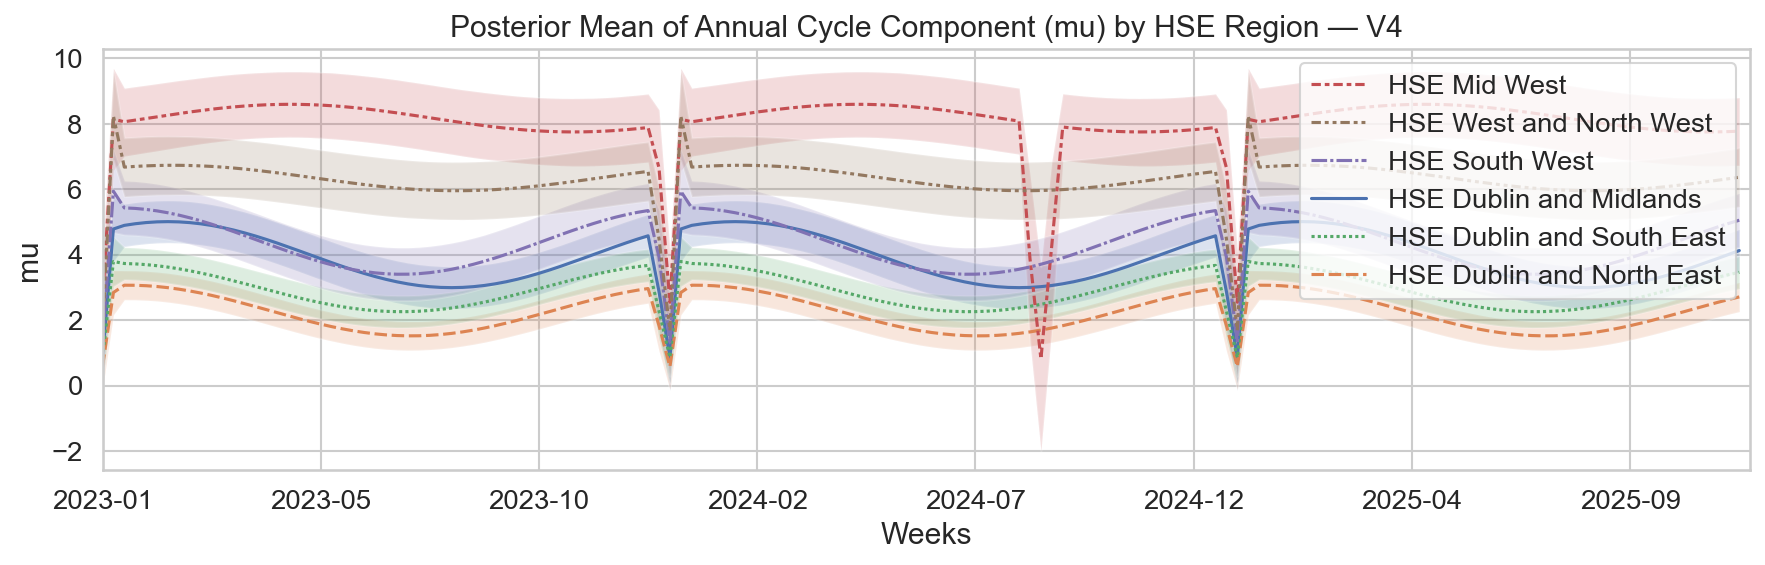

In [64]:
plt.figure(figsize=(12, 4), dpi=150)
axs = sns.lineplot(data=df_mu)
for col in df_mu.columns:
    plt.fill_between(df_mu.index, df_mu_lower[col], df_mu_upper[col], alpha=0.2)
axs.set_title('Posterior Mean of Annual Cycle Component (mu) by HSE Region — V4')
axs.set_xlabel('Weeks')
axs.set_ylabel('mu')
axs.set_xlim(0, df_mu.shape[0])
axs.set_xticks(df_mu.index[::20])
x_labels = pd.to_datetime('2023-01-01') + pd.to_timedelta(df_mu.index, unit='W')
x_labels = x_labels.strftime('%Y-%m')
axs.set_xticklabels(x_labels[::20])
handles, labels = plt.gca().get_legend_handles_labels()
order = [3,5,4,0,2,1]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], loc='upper right')
plt.tight_layout()

## Alpha Intercepts & Cost-Scaled Expectation

$\alpha_i$ is the region-specific intercept estimated with the hierarchical prior $\alpha_i \sim \mathcal{N}(\mu_\lambda \cdot c_i, \tau_\alpha)$.

**CostScaled** = $\hat{\mu}_\lambda \cdot c_i$ (what the model expects given per-capita cost alone).  
**Deviation** = $\hat{\alpha}_i - \hat{\mu}_\lambda \cdot c_i$ (how much each region's intercept departs from the cost-scaled expectation).

In [ ]:
mu_lambda_mean = raw_df['mu_lambda'].mean()

df_alpha = pd.DataFrame({
    'Alpha_Mean':  [raw_df[f'alpha[{i+1}]'].mean() for i in range(n_region)],
    'Alpha_SD':    [raw_df[f'alpha[{i+1}]'].std()  for i in range(n_region)],
    'CostPerPerson': cost_per_person,
    'mu_lambda': mu_lambda_mean,
    'CostScaled':  [mu_lambda_mean * cost_per_person[i] for i in range(n_region)],
    'Deviation':   [raw_df[f'alpha[{i+1}]'].mean() - mu_lambda_mean * cost_per_person[i]
                    for i in range(n_region)],
}, index=regions)

print(f'mu_lambda posterior mean: {mu_lambda_mean:.4f}')
df_alpha.sort_values('Alpha_Mean', ascending=False).round(3)

mu_lambda posterior mean: 1.5794


,Alpha_Mean,Alpha_SD,CostPerPerson,CostScaled,Deviation
HSE Mid West,8.175,0.308,2.862,4.519,3.656
HSE West and North West,6.346,0.267,3.307,5.223,1.123
HSE South West,4.421,0.243,2.703,4.269,0.151
HSE Dublin and Midlands,4.005,0.192,3.406,5.379,-1.374
HSE Dublin and South East,2.999,0.147,2.738,4.325,-1.325
HSE Dublin and North East,2.297,0.132,2.860,4.517,-2.220


## Plot Full AR1 Model

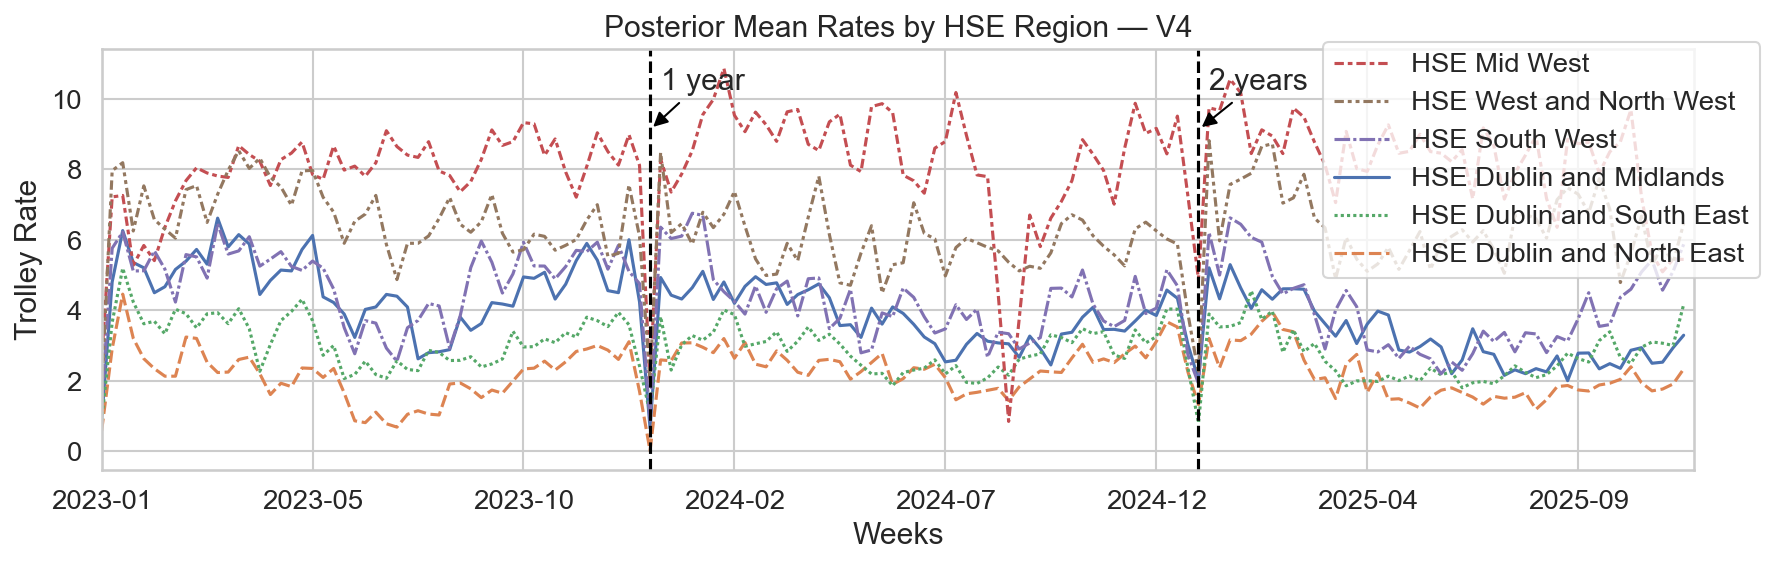

In [66]:
plt.figure(figsize=(12, 4), dpi=150)
axs = sns.lineplot(data=df_ar1)
axs.axvline(x=104, color='black', linestyle='--')
axs.axvline(x=52,  color='black', linestyle='--')
axs.annotate('2 years', xy=(104, plt.ylim()[1]*0.8), xytext=(105, plt.ylim()[1]*.90),
             arrowprops=dict(arrowstyle='-|>', color='black'))
axs.annotate('1 year',  xy=(52,  plt.ylim()[1]*0.8), xytext=(53,  plt.ylim()[1]*.90),
             arrowprops=dict(arrowstyle='-|>', color='black'))
axs.set_xlim(0, df_ar1.shape[0])
axs.set_title('Posterior Mean Rates by HSE Region — V4')
axs.set_xlabel('Weeks')
axs.set_ylabel('Trolley Rate')
axs.set_xticks(df_ar1.index[::20])
x_labels = pd.to_datetime('2023-01-01') + pd.to_timedelta(df_ar1.index, unit='W')
x_labels = x_labels.strftime('%Y-%m')
axs.set_xticklabels(x_labels[::20])
handles, labels = plt.gca().get_legend_handles_labels()
order = [3,5,4,0,2,1]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order],
           loc='upper right', bbox_to_anchor=(1.05, 1.05))
plt.tight_layout()

## Plot the residuals

In [67]:
df_residuals = df_og - df_ar1
df_std_resid = df_residuals / df_residuals.std()

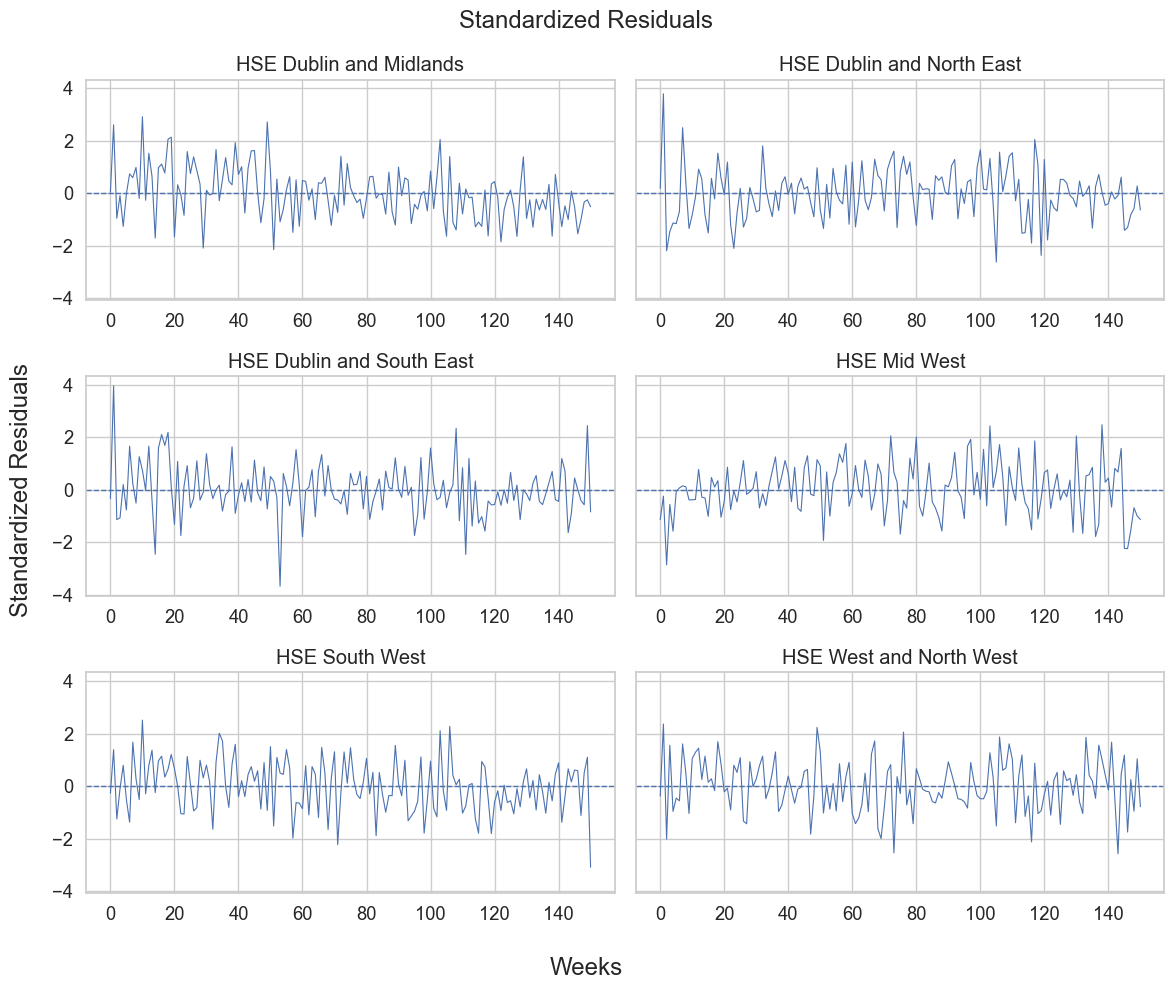

In [68]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=True)
for col, ax in zip(df_std_resid.columns, axes.flatten()):
    ax.plot(df_std_resid[col], linewidth=0.8)
    ax.axhline(y=0, linestyle='--', linewidth=1)
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.suptitle('Standardized Residuals')
fig.supxlabel('Weeks')
fig.supylabel('Standardized Residuals')
plt.tight_layout()

### Autocorrelation of Residuals

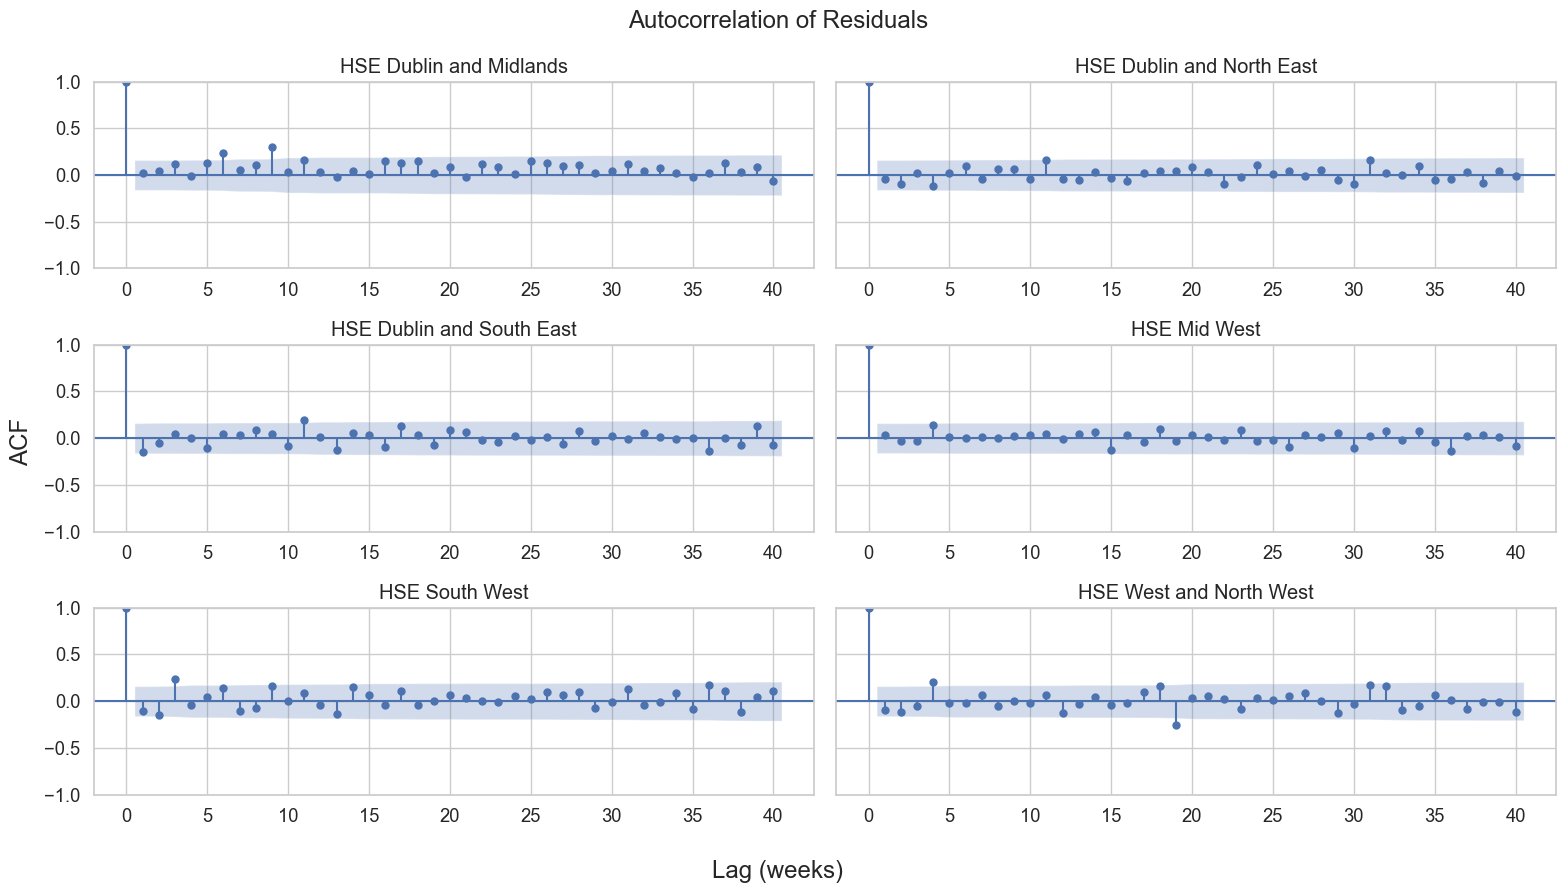

In [69]:
fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharey=True)
for ax, col in zip(axes.flatten(), df_std_resid.columns):
    plot_acf(df_std_resid[col].dropna(), ax=ax, lags=40, alpha=0.05)
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.suptitle('Autocorrelation of Residuals')
fig.supxlabel('Lag (weeks)')
fig.supylabel('ACF')
plt.tight_layout()

### Residuals vs Fitted

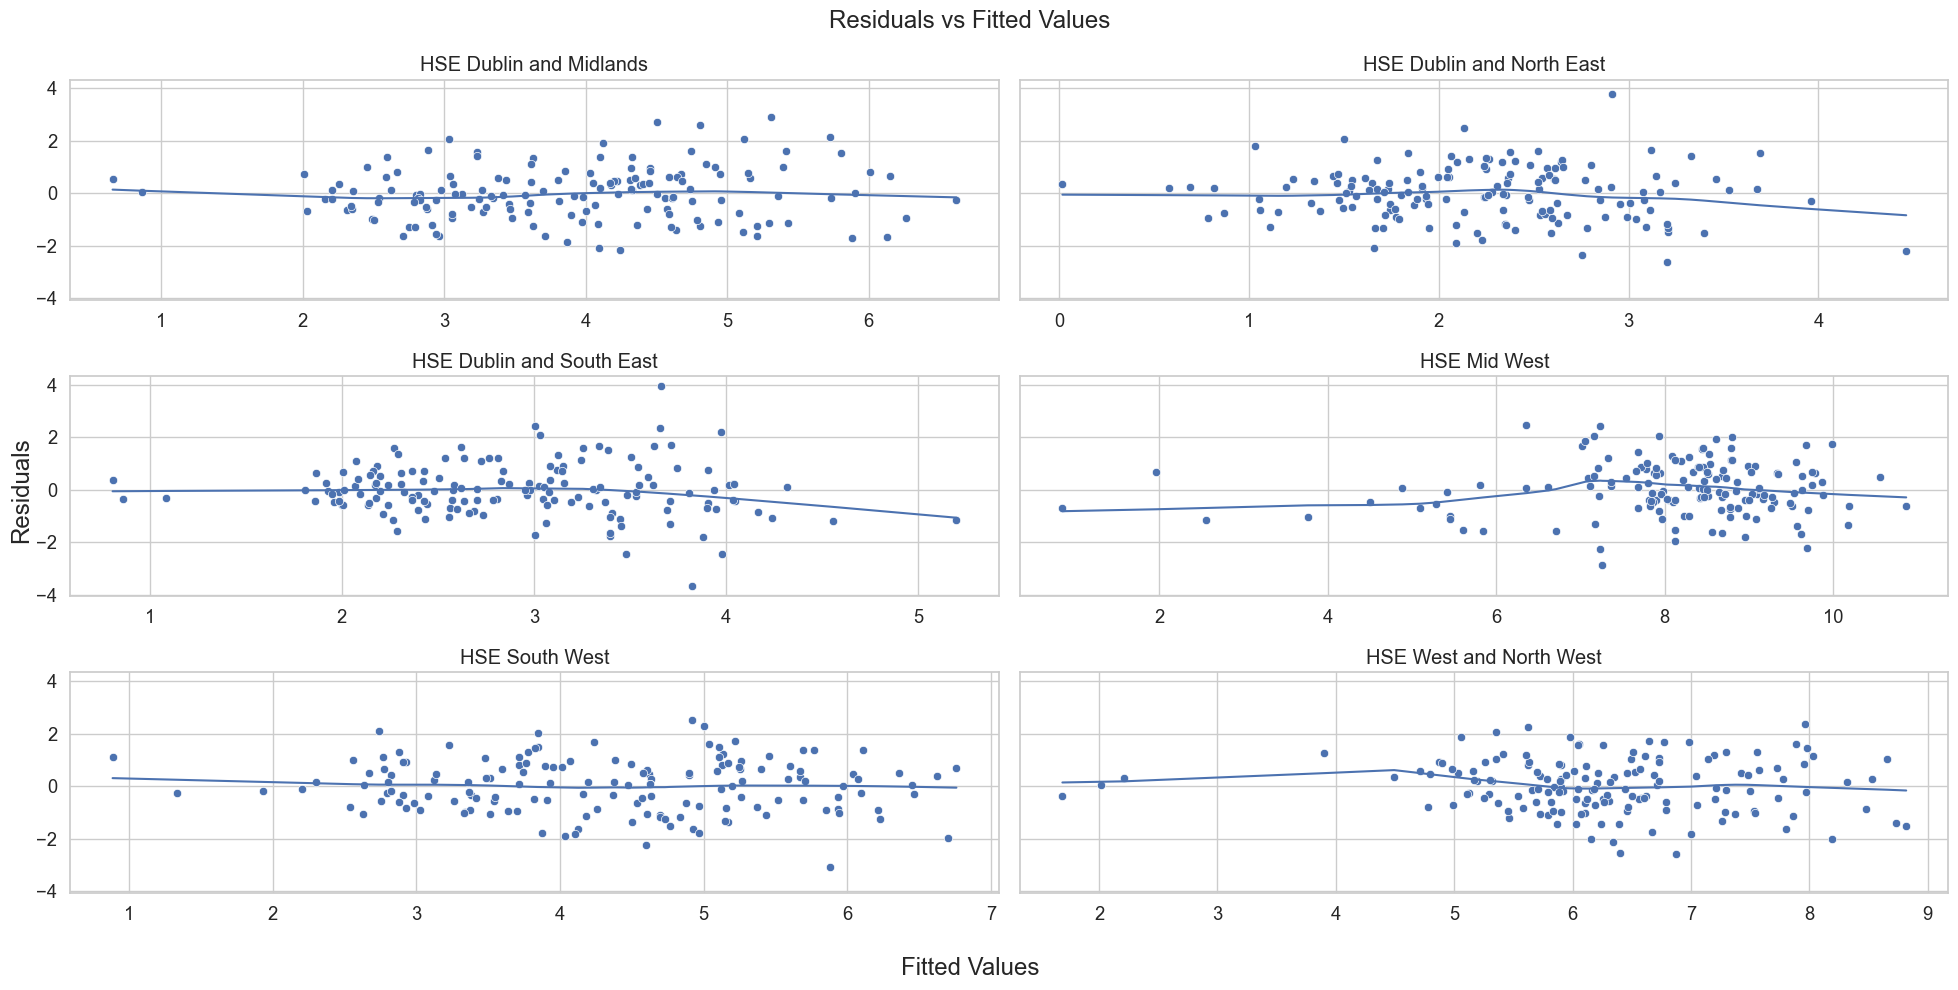

In [70]:
fig, axes = plt.subplots(3, 2, figsize=(20, 10), sharey=True)
for col, ax in zip(df_std_resid.columns, axes.flatten()):
    sns.scatterplot(x=df_ar1[col], y=df_std_resid[col], ax=ax)
    smooth = lowess(df_std_resid[col], df_ar1[col], frac=2/3, return_sorted=True)
    sns.lineplot(x=smooth[:, 0], y=smooth[:, 1], ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.suptitle('Residuals vs Fitted Values')
fig.supxlabel('Fitted Values')
fig.supylabel('Residuals')
plt.tight_layout()

### QQ-Plot For Residuals

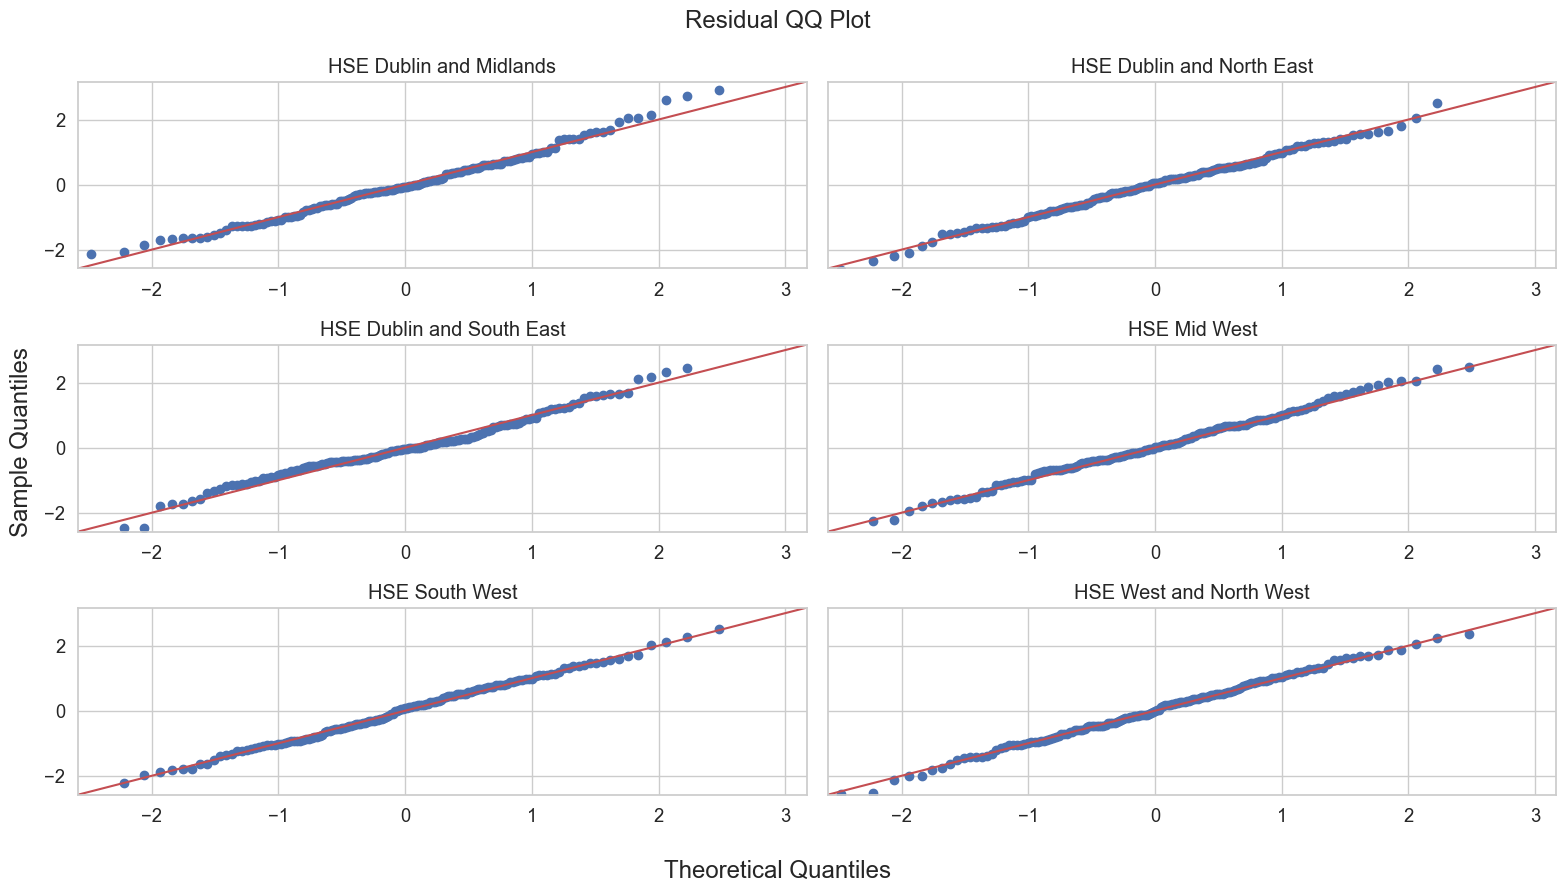

In [71]:
fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharey=True)
for i, (ax, col) in enumerate(zip(axes.flatten(), df_std_resid.columns)):
    qqplot(df_std_resid[col], line='45', ax=ax)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(col)
fig.suptitle('Residual QQ Plot')
fig.supxlabel('Theoretical Quantiles')
fig.supylabel('Sample Quantiles')
plt.tight_layout()

# Significance Testing

### Bonferroni correction

In [72]:
def calc_bonf(n_comparisons, one_sided=False):
    alpha = 0.05 / n_comparisons
    if one_sided:
        lower_q = alpha
        upper_q = 1 - alpha
    else:
        lower_q = alpha / 2
        upper_q = 1 - alpha / 2
    side = "one-sided" if one_sided else "two-sided"
    print(f"n_comparisons={n_comparisons}, alpha={alpha:.6f}, "
          f"lower_q={lower_q:.6f}, upper_q={upper_q:.6f} ({side})")
    return alpha, lower_q, upper_q

### Amplitude overall (one-sided)
$$\hat{A} = \sqrt{\beta^2 + \gamma^2}$$
$$H_0: A_i = 0 $$
$$ H_a: A_i > 0$$

In [73]:
samples = raw_df.filter(regex='beta|gamma')

ampl = {}
for i in range(n_region):
    b = samples[f'beta[{i+1}]']
    g = samples[f'gamma[{i+1}]']
    ampl[regions[i]] = np.sqrt(b**2 + g**2)

In [74]:
alpha, lower_q, upper_q = calc_bonf(n_region, one_sided=True)

results = []
for region in regions:
    ci_lower = np.quantile(ampl[region], lower_q)
    ci_upper = np.quantile(ampl[region], upper_q)
    results.append({
        'Region': region,
        'Mean': ampl[region].mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 else 'No'
    })
pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)

n_comparisons=6, alpha=0.008333, lower_q=0.008333, upper_q=0.991667 (one-sided)


,Region,Mean,0.83%,99.17%,Sig
4,HSE South West,1.071,0.310,1.862,Yes
0,HSE Dublin and Midlands,1.043,0.428,1.668,Yes
1,HSE Dublin and North East,0.795,0.367,1.229,Yes
2,HSE Dublin and South East,0.764,0.297,1.243,Yes
3,HSE Mid West,0.645,0.067,1.549,Yes
5,HSE West and North West,0.576,0.062,1.362,Yes


### Amplitude pairwise

In [75]:
alpha, lower_q, upper_q = calc_bonf(len(list(combinations(range(n_region), 2))))

results = []
for r1, r2 in combinations(range(n_region), 2):
    diff = ampl[regions[r1]] - ampl[regions[r2]]
    ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
    results.append({
        'Region1': regions[r1], 'Region2': regions[r2],
        'MeanDiff': diff.mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })
pd.DataFrame(results).round(3)

n_comparisons=15, alpha=0.003333, lower_q=0.001667, upper_q=0.998333 (two-sided)


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,0.248,-0.678,1.189,No
1,HSE Dublin and Midlands,HSE Dublin and South East,0.279,-0.674,1.248,No
2,HSE Dublin and Midlands,HSE Mid West,0.398,-0.953,1.484,No
3,HSE Dublin and Midlands,HSE South West,-0.028,-1.260,1.189,No
4,HSE Dublin and Midlands,HSE West and North West,0.467,-0.773,1.501,No
5,HSE Dublin and North East,HSE Dublin and South East,0.031,-0.770,0.817,No
6,HSE Dublin and North East,HSE Mid West,0.150,-1.120,1.044,No
7,HSE Dublin and North East,HSE South West,-0.276,-1.390,0.786,No
8,HSE Dublin and North East,HSE West and North West,0.219,-0.908,1.061,No
9,HSE Dublin and South East,HSE Mid West,0.119,-1.136,1.063,No


### Phase radians overall
$$\text{Phase} = \tan^{-1}\left(\frac{-\gamma}{\beta}\right)$$

In [76]:
alpha, lower_q, upper_q = calc_bonf(n_region)

samples = raw_df.filter(regex='beta|gamma')
phase = {}
for i in range(n_region):
    b = samples[f'beta[{i+1}]']
    g = samples[f'gamma[{i+1}]']
    phase[regions[i]] = np.arctan2(-g, b)

results = []
for region in regions:
    ci_lower, ci_upper = np.quantile(phase[region], [lower_q, upper_q])
    results.append({
        'Region': region, 'Mean': phase[region].mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_phase_overall = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
df_phase_overall

n_comparisons=6, alpha=0.008333, lower_q=0.004167, upper_q=0.995833 (two-sided)


,Region,Mean,0.42%,99.58%,Sig
2,HSE Dublin and South East,-0.287,-1.112,0.508,No
4,HSE South West,-0.292,-1.395,0.767,No
1,HSE Dublin and North East,-0.400,-1.075,0.265,No
5,HSE West and North West,-0.727,-3.047,3.041,No
0,HSE Dublin and Midlands,-0.844,-1.623,-0.082,Yes
3,HSE Mid West,-1.156,-3.122,3.120,No


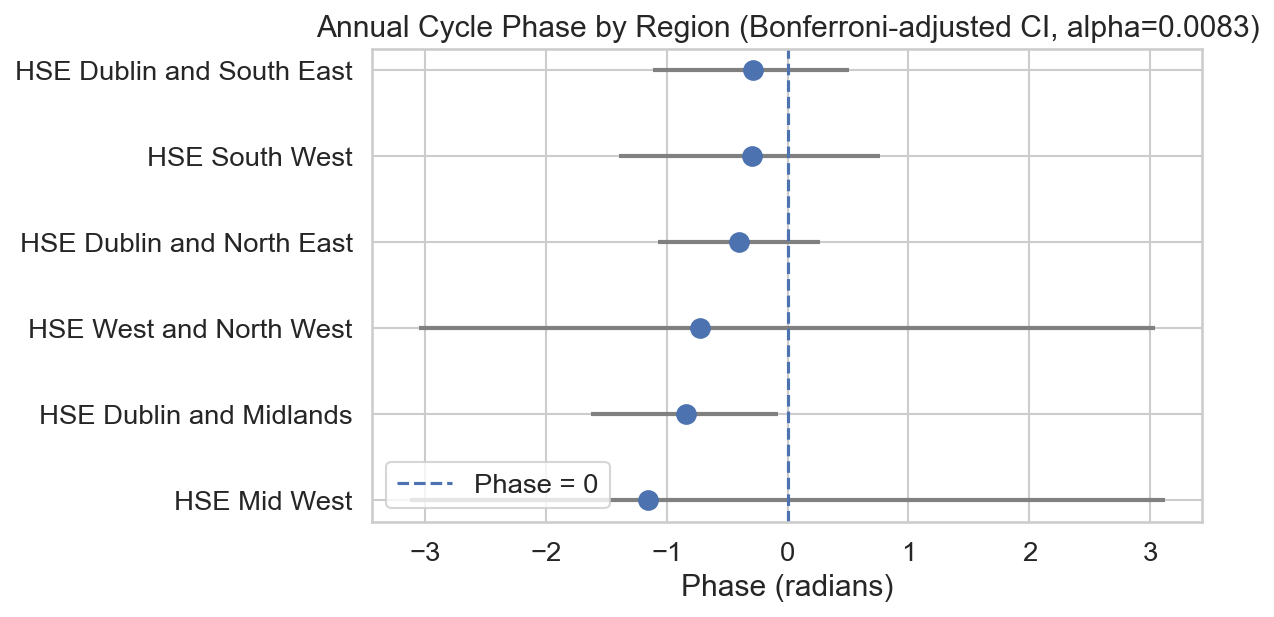

In [77]:
lo_col_phase = f'{lower_q*100:.2f}%'
hi_col_phase = f'{upper_q*100:.2f}%'
df_plot = df_phase_overall.sort_values('Mean')

fig, ax = plt.subplots(figsize=(8, 4), dpi=150, layout='constrained')
y_pos = range(len(df_plot))
ax.hlines(y_pos, df_plot[lo_col_phase], df_plot[hi_col_phase], color='grey', linewidth=2, zorder=1)
ax.scatter(df_plot['Mean'], y_pos, s=80, zorder=2)
ax.axvline(0, linestyle='--', linewidth=1.5, label='Phase = 0')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_plot['Region'].values)
ax.set_xlabel('Phase (radians)')
ax.set_title(f'Annual Cycle Phase by Region (Bonferroni-adjusted CI, alpha={alpha:.4f})')
ax.legend(loc='lower left')
plt.show()

### Phase cycles overall

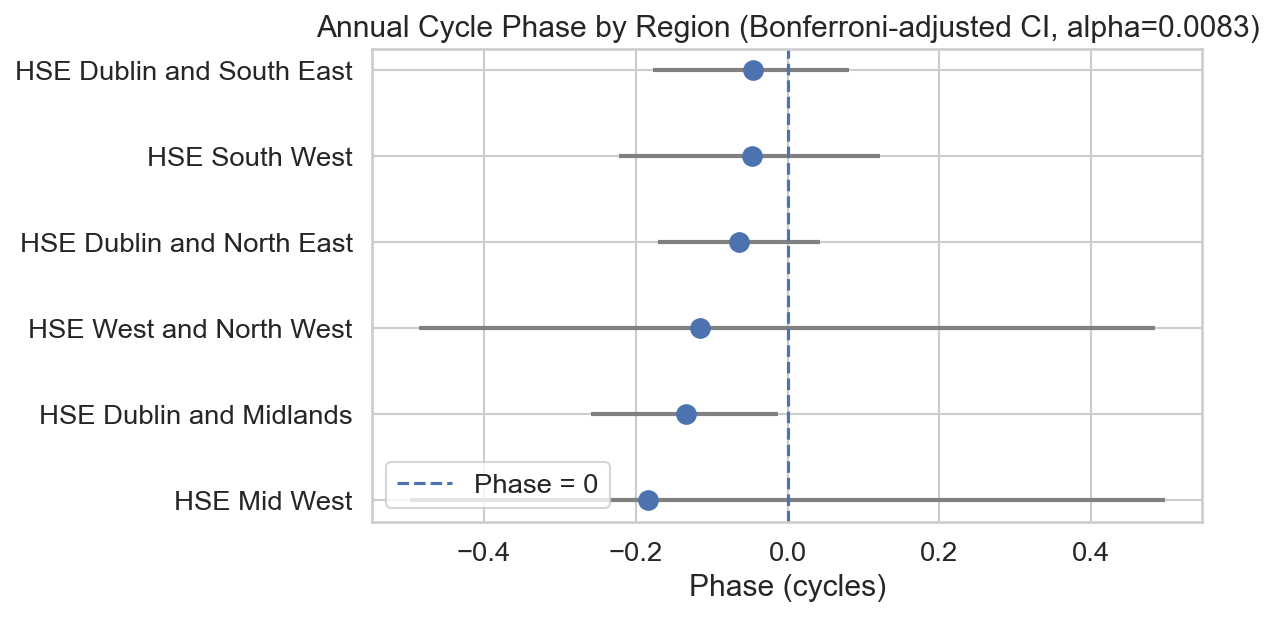

In [78]:
df_plot = df_phase_overall.copy()
df_plot.iloc[:,1:4] = df_plot.iloc[:,1:4] / (2 * np.pi)
df_plot = df_plot.sort_values('Mean')

fig, ax = plt.subplots(figsize=(8, 4), dpi=150, layout='constrained')
y_pos = range(len(df_plot))
ax.hlines(y_pos, df_plot[lo_col_phase], df_plot[hi_col_phase], color='grey', linewidth=2, zorder=1)
ax.scatter(df_plot['Mean'], y_pos, s=80, zorder=2)
ax.axvline(0, linestyle='--', linewidth=1.5, label='Phase = 0')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_plot['Region'].values)
ax.set_xlabel('Phase (cycles)')
ax.set_title(f'Annual Cycle Phase by Region (Bonferroni-adjusted CI, alpha={alpha:.4f})')
ax.legend(loc='lower left')
plt.show()

### Alpha — intercept pairwise
Tests on $\alpha_i$ directly (the region intercepts).

In [79]:
alpha, lower_q, upper_q = calc_bonf(len(list(combinations(range(n_region), 2))))

alpha_samples = {regions[i]: raw_df[f'alpha[{i+1}]'].values for i in range(n_region)}

results = []
for r1, r2 in combinations(range(n_region), 2):
    diff = alpha_samples[regions[r1]] - alpha_samples[regions[r2]]
    ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
    results.append({
        'Region1': regions[r1], 'Region2': regions[r2],
        'MeanDiff': diff.mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })
pd.DataFrame(results).round(3)

n_comparisons=15, alpha=0.003333, lower_q=0.001667, upper_q=0.998333 (two-sided)


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,1.708,1.016,2.410,Yes
1,HSE Dublin and Midlands,HSE Dublin and South East,1.006,0.282,1.726,Yes
2,HSE Dublin and Midlands,HSE Mid West,-4.171,-5.231,-3.066,Yes
3,HSE Dublin and Midlands,HSE South West,-0.416,-1.341,0.510,No
4,HSE Dublin and Midlands,HSE West and North West,-2.341,-3.319,-1.333,Yes
5,HSE Dublin and North East,HSE Dublin and South East,-0.702,-1.288,-0.102,Yes
6,HSE Dublin and North East,HSE Mid West,-5.878,-6.851,-4.850,Yes
7,HSE Dublin and North East,HSE South West,-2.123,-2.952,-1.297,Yes
8,HSE Dublin and North East,HSE West and North West,-4.049,-4.938,-3.149,Yes
9,HSE Dublin and South East,HSE Mid West,-5.176,-6.184,-4.130,Yes


### Global cost coefficient $\mu_\lambda$
$$H_0: \mu_\lambda = 0 \quad H_a: \mu_\lambda \neq 0$$

Tests whether per-capita HR cost has a significant global relationship with the baseline trolley rate.
$\mu_\lambda > 0$ means higher per-capita spend is associated with higher trolley burden at baseline; $\mu_\lambda < 0$ would suggest higher-funded regions have lower burden.

In [80]:
alpha_bonf, lower_q_ml, upper_q_ml = calc_bonf(1)  # single test

mu_lam_vals = raw_df['mu_lambda'].values
ci_lower, ci_upper = np.quantile(mu_lam_vals, [lower_q_ml, upper_q_ml])

df_mu_lam = pd.DataFrame([{
    'Parameter':   'mu_lambda',
    'Mean':        mu_lam_vals.mean(),
    'SD':          mu_lam_vals.std(),
    f'{lower_q_ml*100:.2f}%': ci_lower,
    f'{upper_q_ml*100:.2f}%': ci_upper,
    'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
}]).round(4)
df_mu_lam

n_comparisons=1, alpha=0.050000, lower_q=0.025000, upper_q=0.975000 (two-sided)


,Parameter,Mean,SD,2.50%,97.50%,Sig
0,mu_lambda,1.5794,0.3822,0.8258,2.3502,Yes


In [81]:
alpha_bonf_n, lower_q_a, upper_q_a = calc_bonf(n_region)

results = []
for i, region in enumerate(regions):
    vals = raw_df[f'alpha[{i+1}]'].values
    ci_lower, ci_upper = np.quantile(vals, [lower_q_a, upper_q_a])
    results.append({
        'Region':          region,
        'CostPerPerson':   round(cost_per_person[i], 4),
        'CostScaled':      round(mu_lambda_mean * cost_per_person[i], 3),
        'Alpha_Mean':      vals.mean(),
        'Alpha_SD':        vals.std(),
        f'Alpha_{lower_q_a*100:.2f}%': ci_lower,
        f'Alpha_{upper_q_a*100:.2f}%': ci_upper,
        'Deviation':       vals.mean() - mu_lambda_mean * cost_per_person[i],
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_alpha_overall = pd.DataFrame(results).sort_values('Alpha_Mean', ascending=False).round(3)
df_alpha_overall

n_comparisons=6, alpha=0.008333, lower_q=0.004167, upper_q=0.995833 (two-sided)


,Region,CostPerPerson,CostScaled,Alpha_Mean,Alpha_SD,Alpha_0.42%,Alpha_99.58%,Deviation,Sig
3,HSE Mid West,2.862,4.519,8.175,0.308,7.329,8.982,3.656,Yes
5,HSE West and North West,3.307,5.223,6.346,0.267,5.626,7.057,1.123,Yes
4,HSE South West,2.703,4.269,4.421,0.243,3.770,5.073,0.151,Yes
0,HSE Dublin and Midlands,3.406,5.379,4.005,0.192,3.490,4.522,-1.374,Yes
2,HSE Dublin and South East,2.738,4.325,2.999,0.147,2.603,3.396,-1.325,Yes
1,HSE Dublin and North East,2.860,4.517,2.297,0.132,1.943,2.654,-2.220,Yes


### Alpha — intercept overall
$$H_0: \alpha_i = 0 \quad H_a: \alpha_i \neq 0$$

Tests whether each region's baseline trolley rate is significantly different from zero.

### Alpha — intercept pairwise (regional differences)
$$H_0: \alpha_i = \alpha_j \quad H_a: \alpha_i \neq \alpha_j$$

Tests whether baseline trolley rates differ significantly between pairs of regions.

In [82]:
alpha_bonf_pw, lower_q_pw, upper_q_pw = calc_bonf(len(list(combinations(range(n_region), 2))))

results = []
for r1, r2 in combinations(range(n_region), 2):
    diff = raw_df[f'alpha[{r1+1}]'].values - raw_df[f'alpha[{r2+1}]'].values
    ci_lower, ci_upper = np.quantile(diff, [lower_q_pw, upper_q_pw])
    results.append({
        'Region1':  regions[r1],
        'Region2':  regions[r2],
        'MeanDiff': diff.mean(),
        f'{lower_q_pw*100:.2f}%': ci_lower,
        f'{upper_q_pw*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_alpha_pw = pd.DataFrame(results).round(3)
df_alpha_pw

n_comparisons=15, alpha=0.003333, lower_q=0.001667, upper_q=0.998333 (two-sided)


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,1.708,1.016,2.410,Yes
1,HSE Dublin and Midlands,HSE Dublin and South East,1.006,0.282,1.726,Yes
2,HSE Dublin and Midlands,HSE Mid West,-4.171,-5.231,-3.066,Yes
3,HSE Dublin and Midlands,HSE South West,-0.416,-1.341,0.510,No
4,HSE Dublin and Midlands,HSE West and North West,-2.341,-3.319,-1.333,Yes
5,HSE Dublin and North East,HSE Dublin and South East,-0.702,-1.288,-0.102,Yes
6,HSE Dublin and North East,HSE Mid West,-5.878,-6.851,-4.850,Yes
7,HSE Dublin and North East,HSE South West,-2.123,-2.952,-1.297,Yes
8,HSE Dublin and North East,HSE West and North West,-4.049,-4.938,-3.149,Yes
9,HSE Dublin and South East,HSE Mid West,-5.176,-6.184,-4.130,Yes


### New Year — delta (per-region)
V4 fits `delta_pre[i]`, `delta_mid[i]`, `delta_post[i]` per region (same as V3).

In [83]:
delta_params = ['delta_pre', 'delta_mid', 'delta_post']
delta_samples = {}
for param in delta_params:
    delta_samples[param] = {}
    for i in range(n_region):
        delta_samples[param][regions[i]] = raw_df[f'{param}[{i+1}]'].values

In [84]:
alpha, lower_q, upper_q = calc_bonf(n_region)

for param in delta_params:
    results = []
    for region in regions:
        vals = delta_samples[param][region]
        ci_lower, ci_upper = np.quantile(vals, [lower_q, upper_q])
        results.append({
            'Region': region, 'Mean': vals.mean(),
            f'{lower_q*100:.2f}%': ci_lower,
            f'{upper_q*100:.2f}%': ci_upper,
            'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
        })
    df_sig = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
    print(f'\n=== Overall: {param} (Bonferroni, {n_region} tests) ===')
    display(df_sig)

n_comparisons=6, alpha=0.008333, lower_q=0.004167, upper_q=0.995833 (two-sided)

=== Overall: delta_pre (Bonferroni, 6 tests) ===


,Region,Mean,0.42%,99.58%,Sig
1,HSE Dublin and North East,-1.174,-2.149,-0.193,Yes
3,HSE Mid West,-1.268,-3.506,0.952,No
2,HSE Dublin and South East,-1.428,-2.512,-0.372,Yes
4,HSE South West,-1.458,-3.277,0.326,No
0,HSE Dublin and Midlands,-1.800,-3.217,-0.372,Yes
5,HSE West and North West,-2.097,-4.065,-0.133,Yes



=== Overall: delta_mid (Bonferroni, 6 tests) ===


,Region,Mean,0.42%,99.58%,Sig
1,HSE Dublin and North East,-2.461,-3.379,-1.534,Yes
2,HSE Dublin and South East,-2.864,-3.891,-1.856,Yes
0,HSE Dublin and Midlands,-3.896,-5.257,-2.562,Yes
4,HSE South West,-4.085,-5.796,-2.377,Yes
5,HSE West and North West,-4.931,-6.774,-3.078,Yes
3,HSE Mid West,-5.419,-7.524,-3.318,Yes



=== Overall: delta_post (Bonferroni, 6 tests) ===


,Region,Mean,0.42%,99.58%,Sig
5,HSE West and North West,1.588,-0.099,3.280,No
4,HSE South West,0.508,-1.021,2.041,No
3,HSE Mid West,0.123,-1.765,2.020,No
2,HSE Dublin and South East,0.060,-0.851,0.986,No
0,HSE Dublin and Midlands,-0.048,-1.279,1.162,No
1,HSE Dublin and North East,-0.215,-1.043,0.624,No


n_comparisons=18, alpha=0.002778, lower_q=0.001389, upper_q=0.998611 (two-sided)


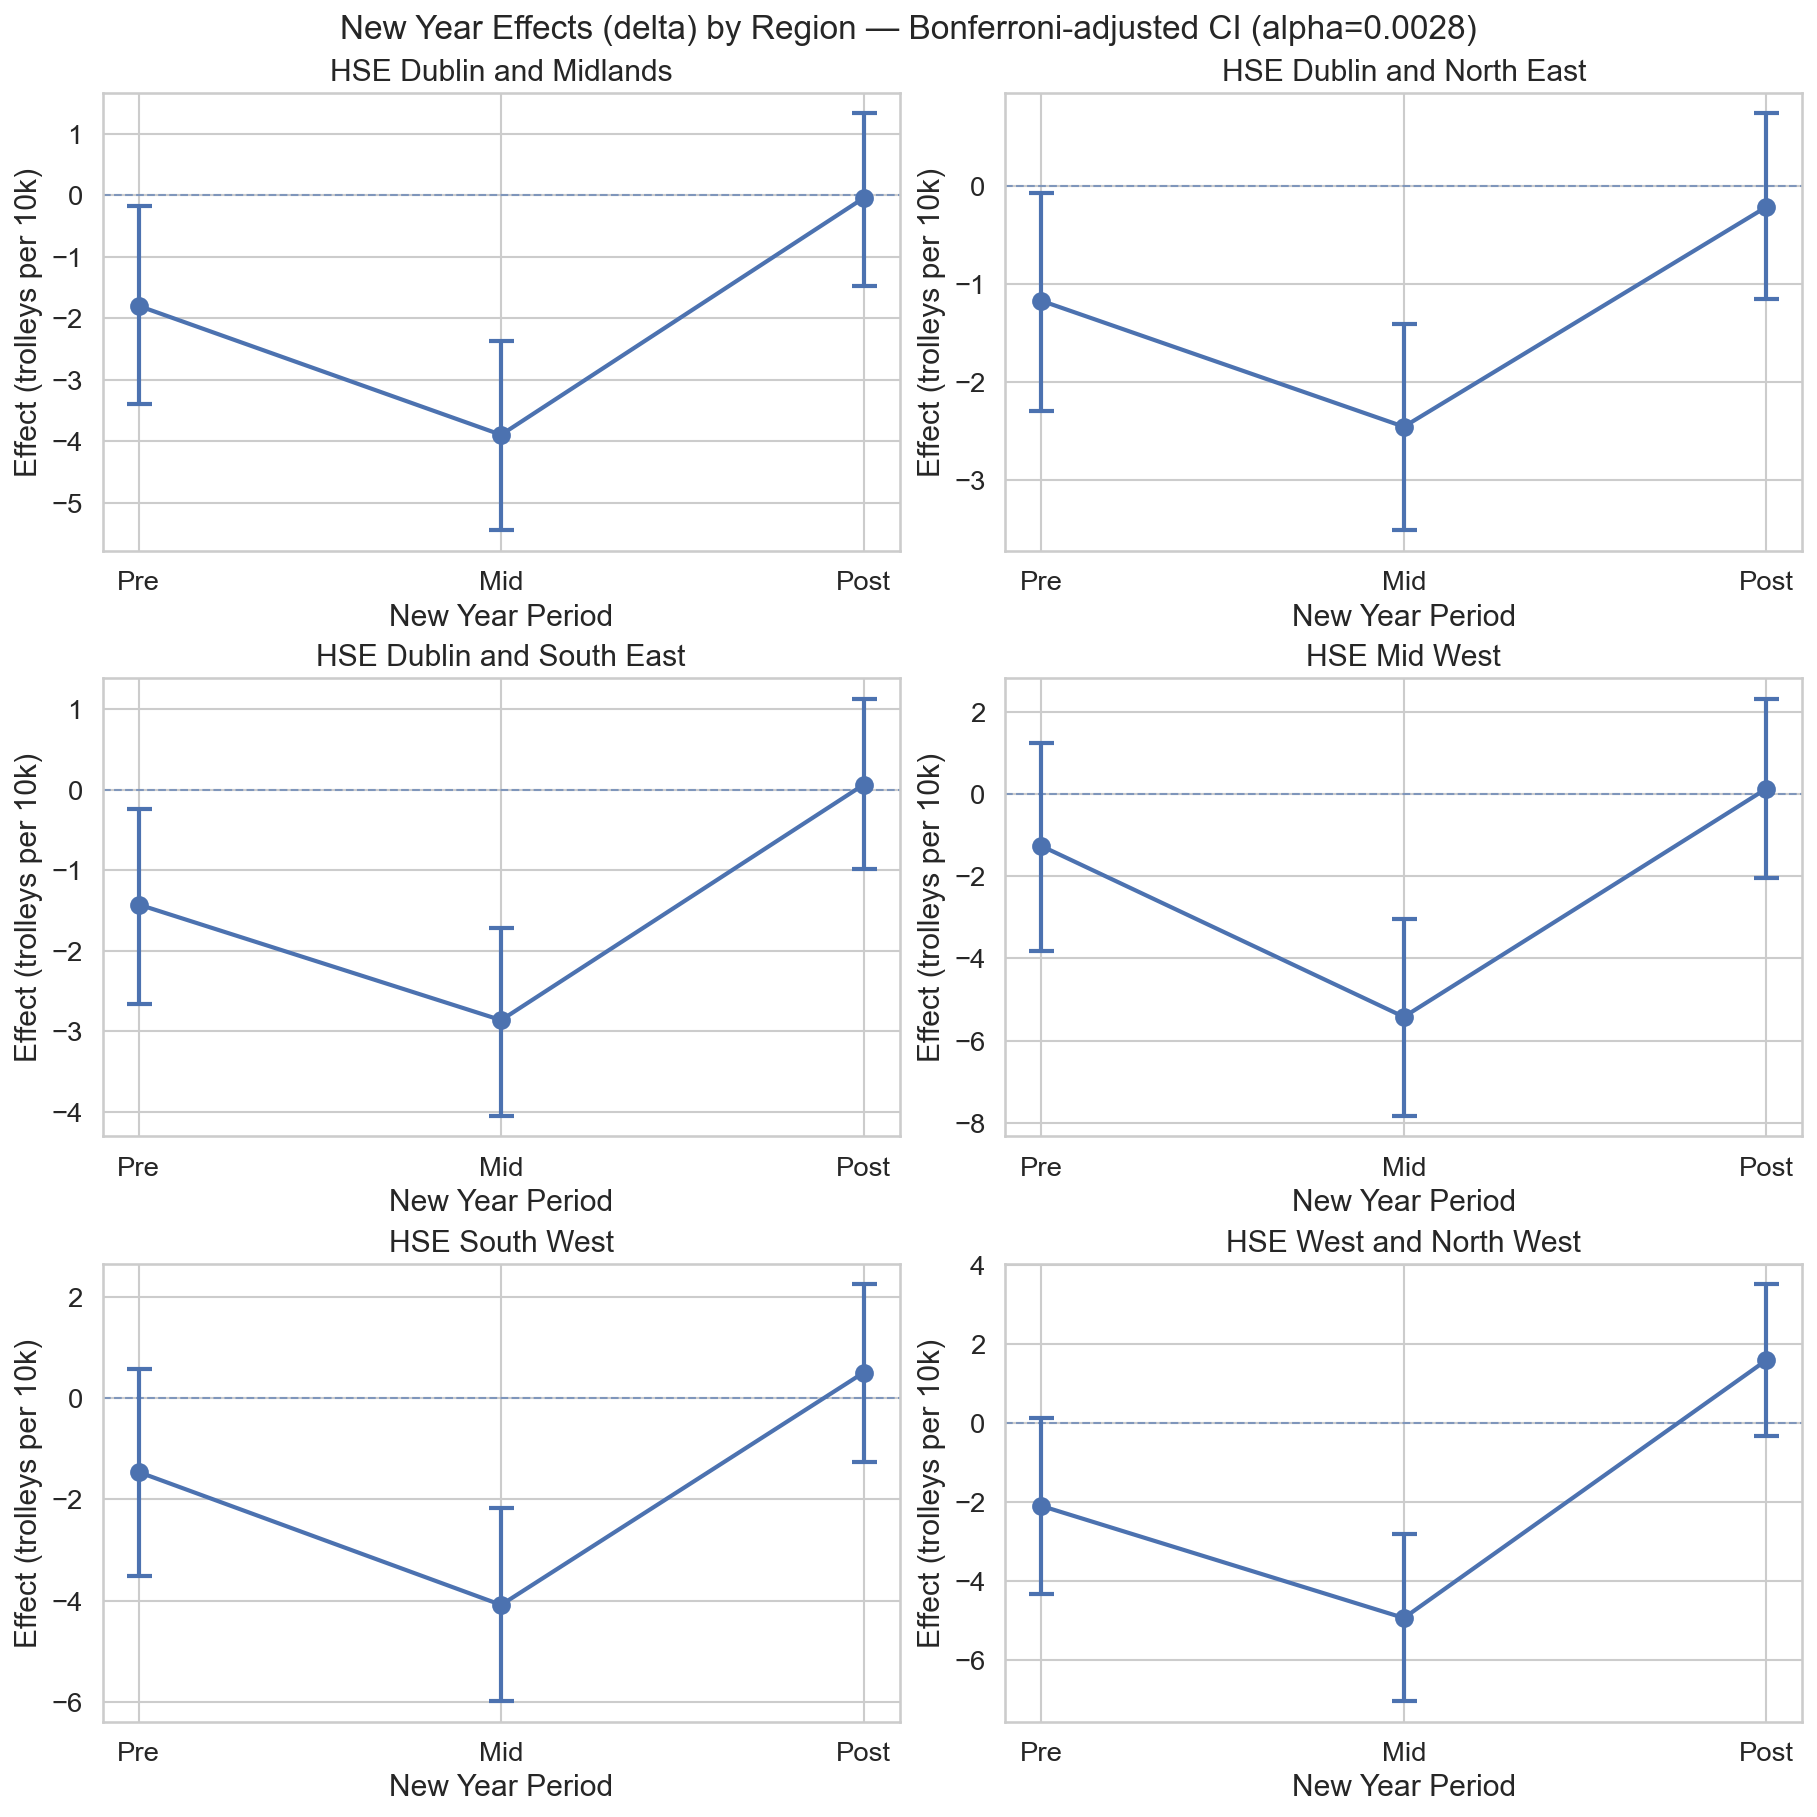

In [85]:
alpha, lower_q, upper_q = calc_bonf(n_region*3)
labels_nice = {'delta_pre': 'Pre', 'delta_mid': 'Mid', 'delta_post': 'Post'}
x_labels = [labels_nice[p] for p in delta_params]

fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=150, layout='constrained')
for idx, (region, ax) in enumerate(zip(regions, axes.flatten())):
    means  = np.array([delta_samples[p][region].mean() for p in delta_params])
    ci_lo  = np.array([np.quantile(delta_samples[p][region], lower_q) for p in delta_params])
    ci_hi  = np.array([np.quantile(delta_samples[p][region], upper_q) for p in delta_params])
    ax.errorbar(x_labels, means, yerr=[means - ci_lo, ci_hi - means],
                fmt='o-', linewidth=2, markersize=8, capsize=6, capthick=2, elinewidth=2, zorder=3)
    ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(region)
    ax.set_xlabel('New Year Period')
    ax.set_ylabel('Effect (trolleys per 10k)')
fig.suptitle(f'New Year Effects (delta) by Region — Bonferroni-adjusted CI (alpha={alpha:.4f})', fontsize=16)
plt.show()

### New Year — delta pairwise (per-region)

In [86]:
alpha, lower_q, upper_q = calc_bonf(len(list(combinations(range(n_region), 2))))

for param in delta_params:
    results = []
    for r1, r2 in combinations(range(n_region), 2):
        diff = delta_samples[param][regions[r1]] - delta_samples[param][regions[r2]]
        ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
        results.append({
            'Region1': regions[r1], 'Region2': regions[r2],
            'MeanDiff': diff.mean(),
            f'{lower_q*100:.2f}%': ci_lower,
            f'{upper_q*100:.2f}%': ci_upper,
            'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
        })
    df_pw = pd.DataFrame(results).round(3)
    print(f'\n=== Pairwise: {param} (Bonferroni, 15 tests) ===')
    display(df_pw)

n_comparisons=15, alpha=0.003333, lower_q=0.001667, upper_q=0.998333 (two-sided)

=== Pairwise: delta_pre (Bonferroni, 15 tests) ===


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,-0.627,-2.494,1.266,No
1,HSE Dublin and Midlands,HSE Dublin and South East,-0.373,-2.354,1.583,No
2,HSE Dublin and Midlands,HSE Mid West,-0.532,-3.489,2.367,No
3,HSE Dublin and Midlands,HSE South West,-0.342,-2.847,2.204,No
4,HSE Dublin and Midlands,HSE West and North West,0.297,-2.392,3.020,No
5,HSE Dublin and North East,HSE Dublin and South East,0.254,-1.338,1.880,No
6,HSE Dublin and North East,HSE Mid West,0.095,-2.587,2.831,No
7,HSE Dublin and North East,HSE South West,0.284,-1.958,2.584,No
8,HSE Dublin and North East,HSE West and North West,0.924,-1.512,3.338,No
9,HSE Dublin and South East,HSE Mid West,-0.159,-2.931,2.580,No



=== Pairwise: delta_mid (Bonferroni, 15 tests) ===


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,-1.435,-3.279,0.354,No
1,HSE Dublin and Midlands,HSE Dublin and South East,-1.032,-2.898,0.857,No
2,HSE Dublin and Midlands,HSE Mid West,1.523,-1.283,4.288,No
3,HSE Dublin and Midlands,HSE South West,0.189,-2.217,2.596,No
4,HSE Dublin and Midlands,HSE West and North West,1.035,-1.535,3.571,No
5,HSE Dublin and North East,HSE Dublin and South East,0.404,-1.141,1.955,No
6,HSE Dublin and North East,HSE Mid West,2.959,0.383,5.493,Yes
7,HSE Dublin and North East,HSE South West,1.625,-0.510,3.760,No
8,HSE Dublin and North East,HSE West and North West,2.471,0.196,4.771,Yes
9,HSE Dublin and South East,HSE Mid West,2.555,-0.070,5.169,No



=== Pairwise: delta_post (Bonferroni, 15 tests) ===


,Region1,Region2,MeanDiff,0.17%,99.83%,Sig
0,HSE Dublin and Midlands,HSE Dublin and North East,0.166,-1.483,1.797,No
1,HSE Dublin and Midlands,HSE Dublin and South East,-0.108,-1.802,1.589,No
2,HSE Dublin and Midlands,HSE Mid West,-0.172,-2.695,2.366,No
3,HSE Dublin and Midlands,HSE South West,-0.556,-2.744,1.636,No
4,HSE Dublin and Midlands,HSE West and North West,-1.636,-3.961,0.677,No
5,HSE Dublin and North East,HSE Dublin and South East,-0.275,-1.651,1.124,No
6,HSE Dublin and North East,HSE Mid West,-0.338,-2.656,2.026,No
7,HSE Dublin and North East,HSE South West,-0.722,-2.678,1.239,No
8,HSE Dublin and North East,HSE West and North West,-1.802,-3.896,0.294,No
9,HSE Dublin and South East,HSE Mid West,-0.063,-2.431,2.285,No


### Full Reset — sigma (global, Mid West only)

In [87]:
alpha, lower_q, upper_q = calc_bonf(3)

sigma_samples_global = raw_df[['sigma_pre', 'sigma_mid', 'sigma_post']]
sigma_params = ['sigma_pre', 'sigma_mid', 'sigma_post']

results = []
for param in sigma_params:
    ci_lower, ci_upper = np.quantile(sigma_samples_global[param], [lower_q, upper_q])
    results.append({
        'Parameter': param, 'Mean': sigma_samples_global[param].mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_sigma_ind = pd.DataFrame(results).round(3)
df_sigma_ind

n_comparisons=3, alpha=0.016667, lower_q=0.008333, upper_q=0.991667 (two-sided)


,Parameter,Mean,0.83%,99.17%,Sig
0,sigma_pre,-4.163,-7.122,-1.162,Yes
1,sigma_mid,-7.170,-10.529,-3.841,Yes
2,sigma_post,-3.640,-6.610,-0.675,Yes


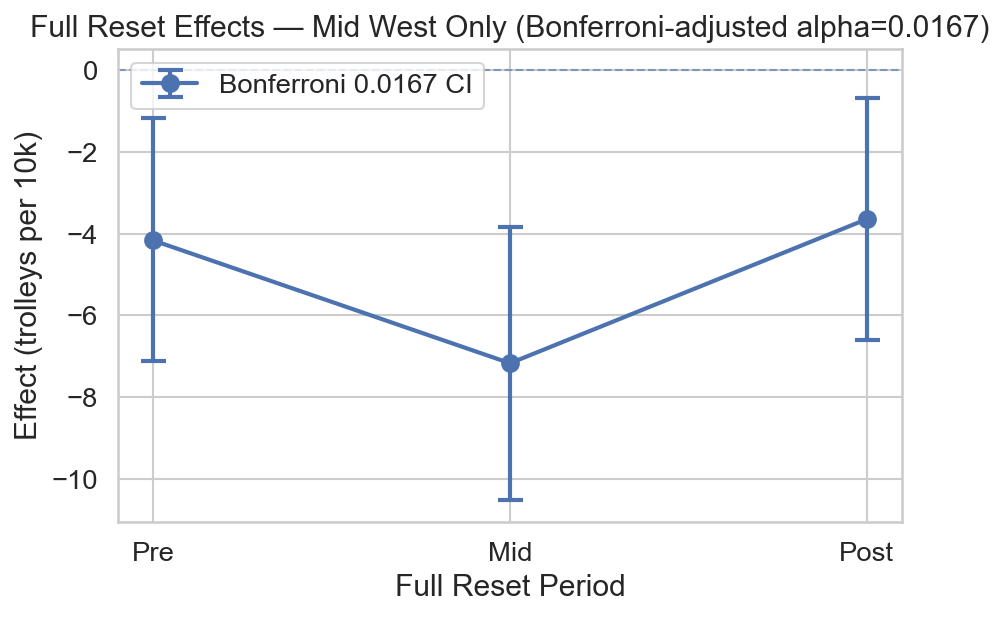

In [88]:
means = df_sigma_ind.iloc[:,1].values
yerr_lower = means - df_sigma_ind.iloc[:, 2].values
yerr_upper = df_sigma_ind.iloc[:, 3].values - means

fig, ax = plt.subplots(figsize=(6, 4), dpi=150, layout='constrained')
ax.errorbar(['Pre', 'Mid', 'Post'], df_sigma_ind['Mean'].values,
            yerr=[yerr_lower, yerr_upper],
            fmt='o-', linewidth=2, markersize=8,
            capsize=6, capthick=2, elinewidth=2, zorder=3,
            label=f'Bonferroni {alpha:.4f} CI')
ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Full Reset Period')
ax.set_ylabel('Effect (trolleys per 10k)')
ax.set_title(f'Full Reset Effects — Mid West Only (Bonferroni-adjusted alpha={alpha:.4f})')
ax.legend()
plt.show()

In [89]:
alpha, lower_q, upper_q = calc_bonf(len(list(combinations(sigma_params, 2))))

results = []
for a, b in combinations(sigma_params, 2):
    diff = sigma_samples_global[a] - sigma_samples_global[b]
    ci_lower, ci_upper = np.quantile(diff, [lower_q, upper_q])
    results.append({
        'Comparison': f'{a} - {b}', 'MeanDiff': diff.mean(),
        f'{lower_q*100:.2f}%': ci_lower,
        f'{upper_q*100:.2f}%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })
pd.DataFrame(results).round(3)

n_comparisons=3, alpha=0.016667, lower_q=0.008333, upper_q=0.991667 (two-sided)


,Comparison,MeanDiff,0.83%,99.17%,Sig
0,sigma_pre - sigma_mid,3.007,-0.082,6.142,No
1,sigma_pre - sigma_post,-0.523,-4.081,3.096,No
2,sigma_mid - sigma_post,-3.530,-6.611,-0.405,Yes


# Ranking
Ranked on $\alpha_i$ (region intercept) per MCMC draw.

Pandas ranking averages ties: 1, 2, 3, 3, 5 → 1, 2, 2.5, 2.5, 4, 5.

### Tables

In [90]:
# Rank alpha[i] across regions per MCMC draw
alpha_df = pd.DataFrame(
    {regions[i]: raw_df[f'alpha[{i+1}]'].values for i in range(n_region)}
)
ranked_alpha = alpha_df.rank(axis=1)
ranked_alpha.head(2)  # sanity check

,HSE Dublin and Midlands,HSE Dublin and North East,HSE Dublin and South East,HSE Mid West,HSE South West,HSE West and North West
0,3.0,1.0,2.0,6.0,4.0,5.0
1,3.0,1.0,2.0,6.0,4.0,5.0


In [91]:
final_ranked_df = pd.DataFrame({
    'Mean of the posterior rank':       ranked_alpha.mean(axis=0),
    'Rank of the posterior rank mean':   ranked_alpha.mean(axis=0).rank(),
    'Rank of the posterior rank median': ranked_alpha.median(axis=0).rank(),
    'SD':   np.sqrt(ranked_alpha.var(axis=0)),
    'Max':  ranked_alpha.max(axis=0),
    'Min':  ranked_alpha.min(axis=0),
    '2.5%': ranked_alpha.quantile(.025),
    '97.5%':ranked_alpha.quantile(.975)
}).sort_values('Mean of the posterior rank', ascending=True).round(4)
final_ranked_df.to_csv('../../data/models/v4/ranks.csv')
final_ranked_df

,Mean of the posterior rank,Rank of the posterior rank mean,Rank of the posterior rank median,SD,Max,Min,2.5%,97.5%
HSE Dublin and North East,1.0003,1.0,1.0,0.0166,2.0,1.0,1.0,1.0
HSE Dublin and South East,1.9998,2.0,2.0,0.0187,3.0,1.0,2.0,2.0
HSE Dublin and Midlands,3.0888,3.0,3.0,0.2847,4.0,2.0,3.0,4.0
HSE South West,3.9111,4.0,4.0,0.2846,4.0,3.0,3.0,4.0
HSE West and North West,5.0000,5.0,5.0,0.0000,5.0,5.0,5.0,5.0
HSE Mid West,6.0000,6.0,6.0,0.0000,6.0,6.0,6.0,6.0


### Distributions of ranks

/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_18504/791117766.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_18504/791117766.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_18504/791117766.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])
/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_18504/791117766.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])


Text(0.5, 0.98, 'Distribution of Posterior Ranks for $\\alpha_i$ (Region Intercept) by Region')

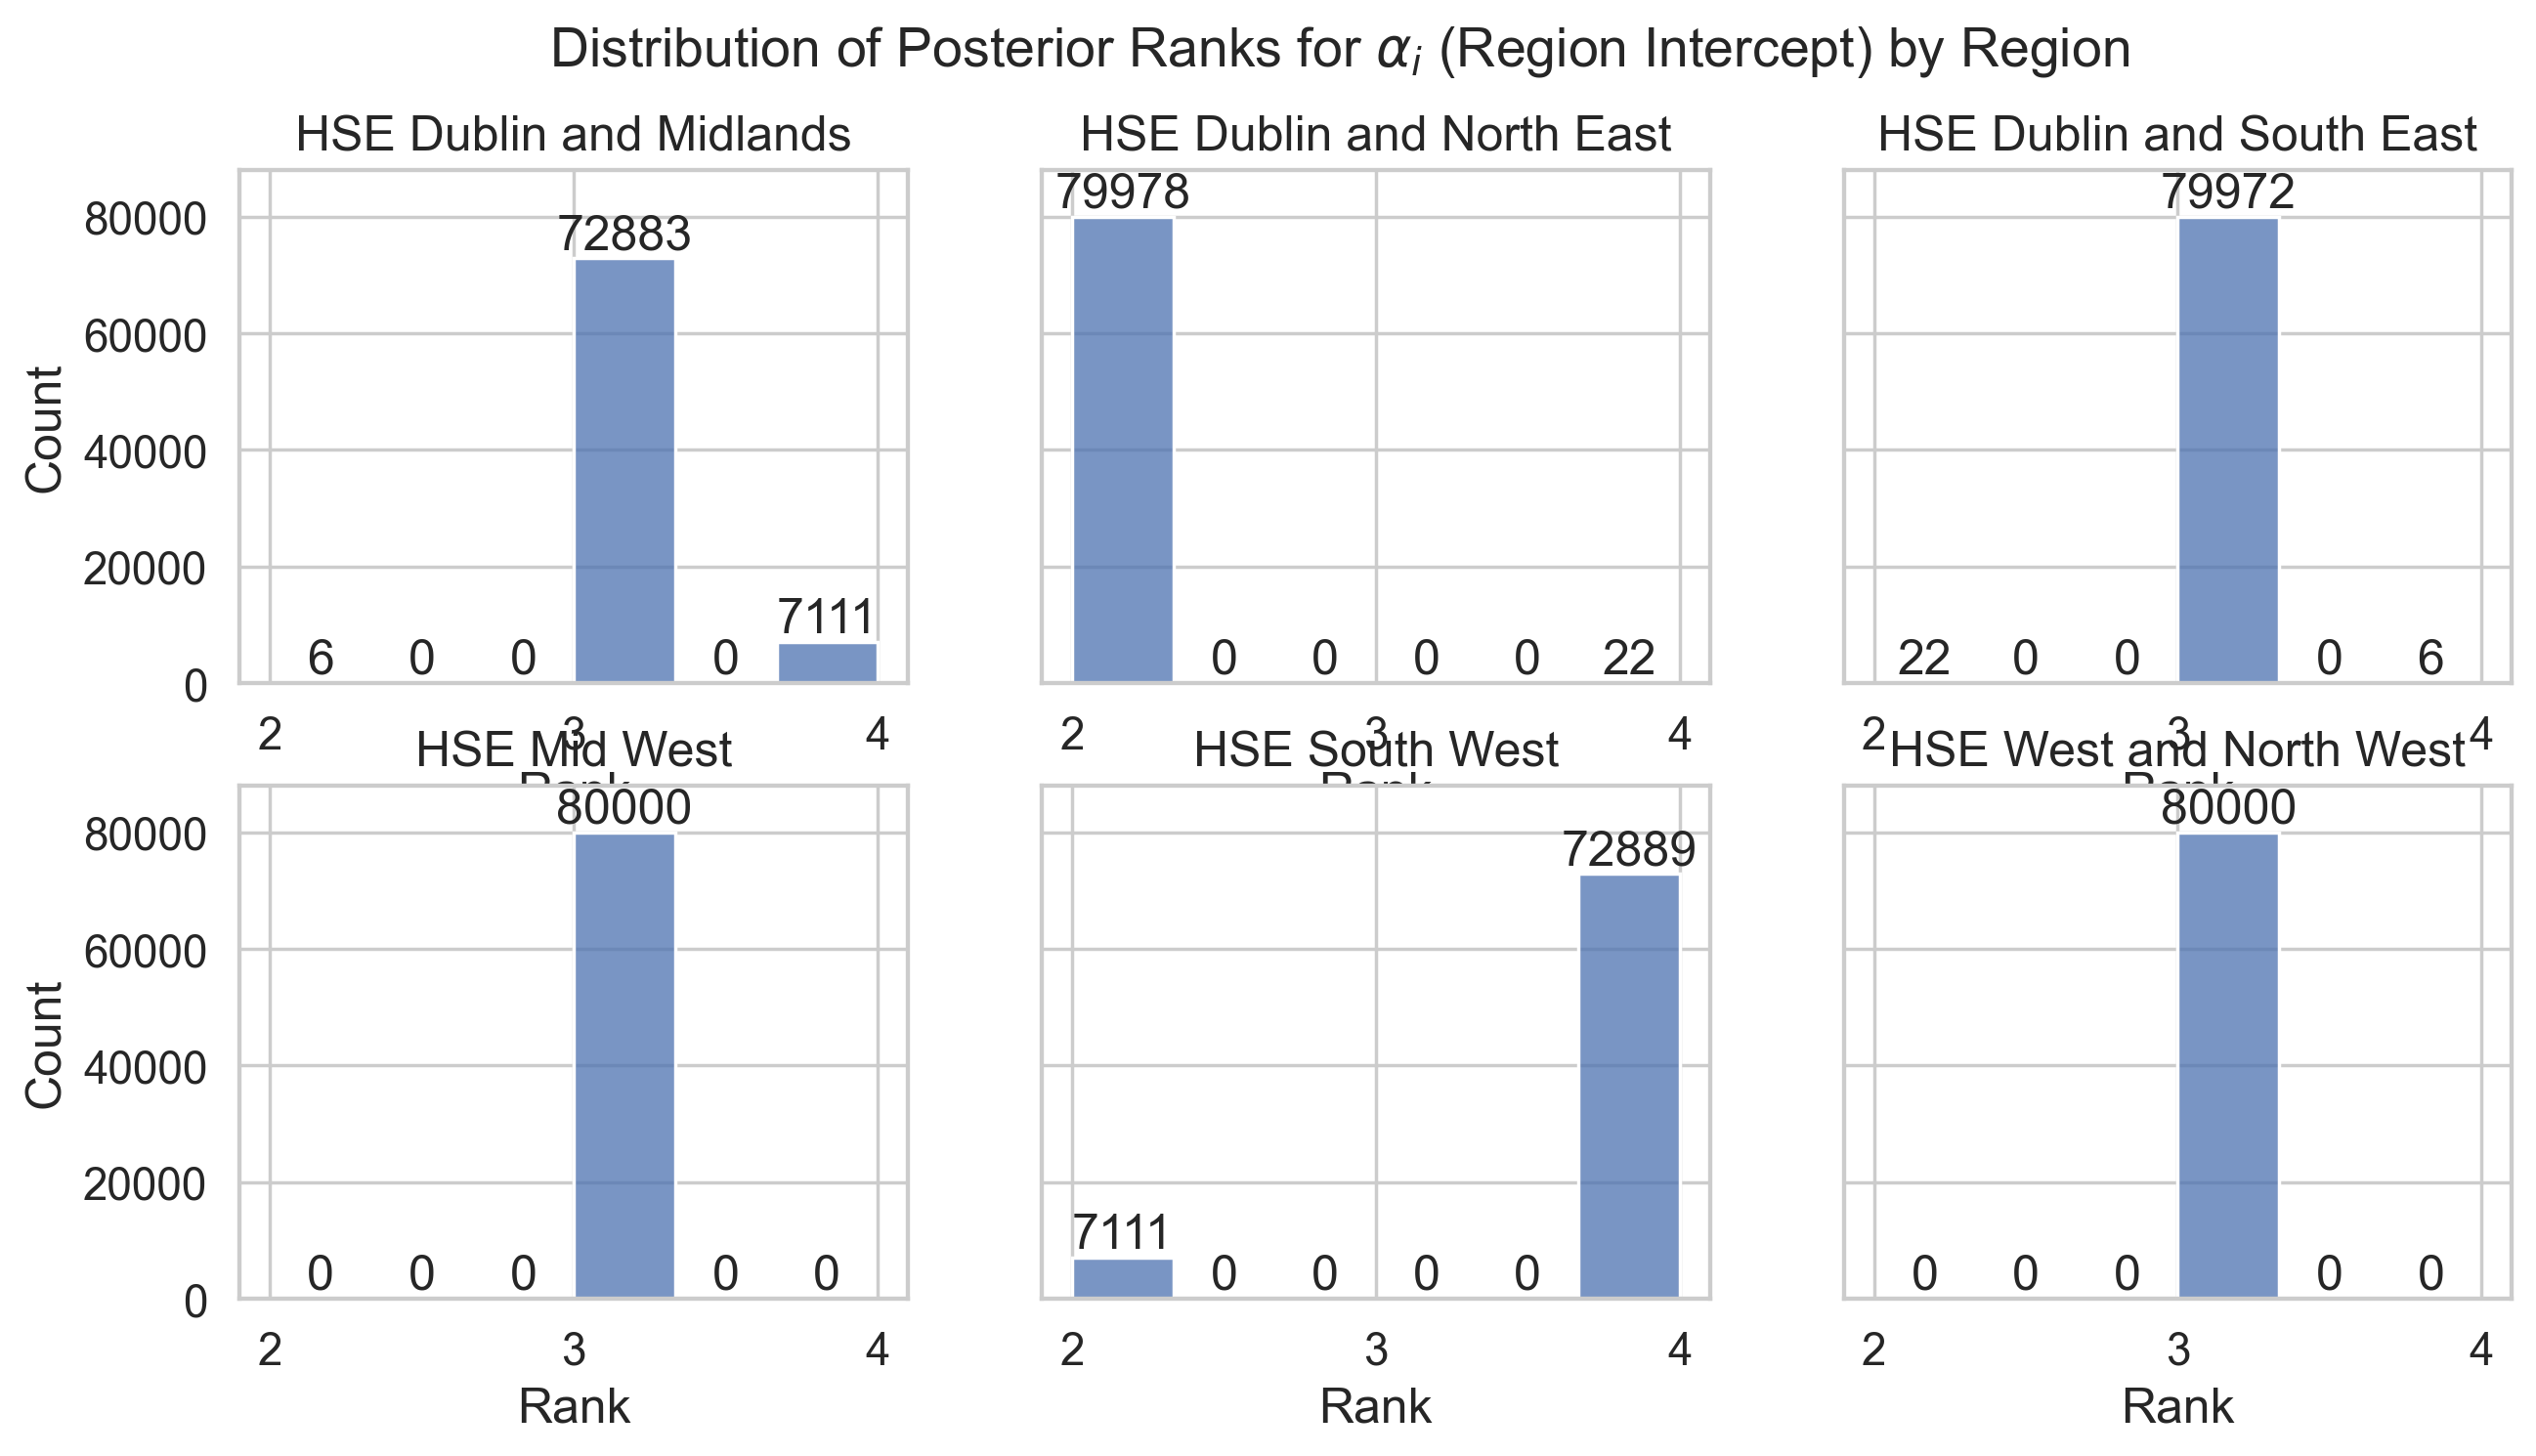

In [92]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=250, sharey=True)
for ax, col in zip(axes.flatten(), ranked_alpha.columns):
    sns.histplot(ranked_alpha[col], bins=6, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Rank')
    ax.margins(y=.1)
    ax.set_xticklabels([1, 2, 3, 4, 5, 6])
    for container in ax.containers: ax.bar_label(container)
fig.suptitle(r'Distribution of Posterior Ranks for $\alpha_i$ (Region Intercept) by Region', fontsize=16)

### Pairwise comparison

In [93]:
lower_q = .025; upper_q = .975
pairwise_test_df = []
for x in combinations(regions, 2):
    difference = ranked_alpha[x[0]] - ranked_alpha[x[1]]
    quantile = np.quantile(difference, [lower_q, upper_q])
    pairwise_test_df.append({
        'Region(1) - Region(2)': f"{x[0]} - {x[1]}",
        '2.5%': quantile[0],
        '97.5%': quantile[1],
        'Significant': 'Yes' if quantile[0] > 0 or quantile[1] < 0 else 'No'
    })
pd.DataFrame(pairwise_test_df)

,Region(1) - Region(2),2.5%,97.5%,Significant
0,HSE Dublin and Midlands - HSE Dublin and North...,2.0,3.0,Yes
1,HSE Dublin and Midlands - HSE Dublin and South...,1.0,2.0,Yes
2,HSE Dublin and Midlands - HSE Mid West,-3.0,-2.0,Yes
3,HSE Dublin and Midlands - HSE South West,-1.0,1.0,No
4,HSE Dublin and Midlands - HSE West and North West,-2.0,-1.0,Yes
5,HSE Dublin and North East - HSE Dublin and Sou...,-1.0,-1.0,Yes
6,HSE Dublin and North East - HSE Mid West,-5.0,-5.0,Yes
7,HSE Dublin and North East - HSE South West,-3.0,-2.0,Yes
8,HSE Dublin and North East - HSE West and North...,-4.0,-4.0,Yes
9,HSE Dublin and South East - HSE Mid West,-4.0,-4.0,Yes
